 ## 06_FEATURE_ENGINEERING
 
Explainable AI Credit Risk Decision Platform Integrating Structured Borrower Data, NLP-Driven Text Intelligence, and Macroeconomic Indicators for Transparent Lending Decisions.

#### Reason:
This is to transform, combine and extract meaningful variable from raw data using domain knowledge so machine learning algorithm can effectively learn patterns to make accurate predictions.

In [ ]:
# Import libraries
# ____________________________________________________________

import warnings
import logging
from pathlib import Path
import os

# Data Manipulation

import numpy as np
import pandas as pd

# SCIKIT-LEARN

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import (TfidfVectorizer)

# SCIPY

from scipy.sparse import (hstack,save_npz)

# SERIALISATION

import joblib


# VISUALISATION

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

warnings.filterwarnings("ignore")

In [112]:
# Project Configuration
# _________________________________________

RANDOM_STATE = 42

TEST_SIZE = 0.20

MAX_TFIDF_FEATURES = 5000

MIN_DOCUMENT_FREQUENCY = 5

TARGET_COLUMN = "target"

TEXT_COLUMN = "clean_title"

In [113]:
# Project Root Directory 
# _________________________________________

PROJECT_ROOT = Path.cwd()

print("Project Root:")

print(PROJECT_ROOT)

Project Root:
/Users/emmanuelahadzi


In [114]:
# Project Directories
# _________________________________________

# Data

DATA_DIR = PROJECT_ROOT / "data"

PROCESSED_DATA_DIR = DATA_DIR / "processed"

FEATURE_STORE_DIR = DATA_DIR / "feature_store"

# Models

MODELS_DIR = PROJECT_ROOT / "models"

PREPROCESSING_DIR = MODELS_DIR / "preprocessing"

# Reports

REPORT_DIR = PROJECT_ROOT / "reports"

FEATURE_REPORT_DIR = REPORT_DIR / "feature_engineering"

FIGURE_DIR = Path("figures")

FIGURE_DIR.mkdir(exist_ok=True)

# Logs

LOG_DIR = PROJECT_ROOT / "logs"

In [115]:
# CREATE DIRECTORIES
# _________________________________________

directories = [

    DATA_DIR,

    PROCESSED_DATA_DIR,

    FEATURE_STORE_DIR,

    MODELS_DIR,

    PREPROCESSING_DIR,

    REPORT_DIR,

    FEATURE_REPORT_DIR,

    LOG_DIR]

for directory in directories:

    directory.mkdir(

        parents=True,

        exist_ok=True)

print("Project folders successfully created.")

Project folders successfully created.


In [116]:
# LOGGING CONFIGURATION
# __________________________________________________________

LOG_FILE = LOG_DIR / "feature_engineering.log"

logging.basicConfig(

    level=logging.INFO,

    format="%(asctime)s | %(levelname)s | %(message)s",

    handlers=[logging.FileHandler(LOG_FILE),
              
              logging.StreamHandler()])

logger = logging.getLogger(__name__)

logger.info("FEATURE ENGINEERING STARTED")


2026-07-16 19:59:46,120 | INFO | FEATURE ENGINEERING STARTED


In [117]:
# Define missing variables with example values
# __________________________________________________________

RANDOM_STATE = 42  

MAX_TFIDF_FEATURES = 5000  

MIN_DOCUMENT_FREQUENCY = 2 

SCALER = "StandardScaler"  

ENCODER = "LabelEncoder" 

FEATURE_REPORT_DIR = Path("./reports")

logger = logging.getLogger(__name__)  

In [118]:
# FEATURE ENGINEERING RUN METADATA
# __________________________________________________________

run_metadata = pd.DataFrame({

    "Item":[

        "Notebook",

        "Random State",

        "Maximum TF-IDF Features",

        "Minimum Document Frequency",

        "Scaler",

        "Encoder",

        "Execution Status"],

    "Value":[

        "04_feature_engineering.ipynb",

        RANDOM_STATE,

        MAX_TFIDF_FEATURES,

        MIN_DOCUMENT_FREQUENCY,

        SCALER,

        ENCODER,

        "Started"]})

display(run_metadata)

run_metadata.to_csv(FEATURE_REPORT_DIR /"run_metadata.csv",index=False)

logger.info("Run metadata exported.")

,Item,Value
0,Notebook,04_feature_engineering.ipynb
1,Random State,42
2,Maximum TF-IDF Features,5000
3,Minimum Document Frequency,2
4,Scaler,StandardScaler
5,Encoder,LabelEncoder
6,Execution Status,Started


2026-07-16 19:59:49,238 | INFO | Run metadata exported.


In [119]:
# Loading Datasets
# __________________________________________________________

X_train = pd.read_csv("data/processed/X_train.csv")

X_test = pd.read_csv("data/processed/X_test.csv")

y_train = pd.read_csv("data/processed/y_train.csv").squeeze()

y_test = pd.read_csv("data/processed/y_test.csv").squeeze()

logger.info("Datasets loaded successfully.")

2026-07-16 19:59:56,869 | INFO | Datasets loaded successfully.


In [120]:
# Dataset Dimensions
# __________________________________________________________

print("DATASET DIMENSIONS")

print(f"X_train : {X_train.shape}")

print(f"X_test  : {X_test.shape}")

print(f"y_train : {y_train.shape}")

print(f"y_test  : {y_test.shape}")

DATASET DIMENSIONS
X_train : (400000, 94)
X_test  : (100000, 94)
y_train : (400000,)
y_test  : (100000,)


In [121]:
# Preview Training Data
# __________________________________________________________

display(X_train.head())

display(y_train.head())

,mths_since_recent_inq,emp_title,emp_length,num_tl_120dpd_2m,mo_sin_old_il_acct,bc_util,percent_bc_gt_75,bc_open_to_buy,mths_since_recent_bc,last_pymnt_d,...,url,grade,pymnt_plan,issue_d,verification_status,annual_inc,home_ownership,disbursement_method,id,clean_title
0,19.0,LAB TECHNICIAN,10+ years,0.0,162.0,95.9,100.0,575.0,57.0,Mar-2019,...,https://lendingclub.com/browse/loanDetail.acti...,B,n,Jan-2015,Source Verified,44096.3,RENT,Cash,38547678,credit card refinancing
1,8.0,Registered Nurse,1 year,0.0,107.0,70.2,66.7,7986.0,8.0,Jan-2017,...,https://lendingclub.com/browse/loanDetail.acti...,A,n,Dec-2015,Not Verified,90000.0,MORTGAGE,Cash,68142357,debt consolidation
2,1.0,Meteorologist,< 1 year,0.0,93.0,71.2,25.0,3482.0,43.0,Oct-2015,...,https://lendingclub.com/browse/loanDetail.acti...,B,n,May-2015,Source Verified,52200.0,RENT,Cash,49773455,debt consolidation
3,8.0,Feeder Driver,10+ years,0.0,31.0,79.8,66.7,2622.0,17.0,Mar-2019,...,https://lendingclub.com/browse/loanDetail.acti...,E,n,Mar-2018,Source Verified,80000.0,MORTGAGE,Cash,130751884,home improvement
4,19.0,Education Coordinator,10+ years,0.0,90.0,52.1,16.7,5749.0,22.0,Jun-2016,...,https://lendingclub.com/browse/loanDetail.acti...,C,n,Sep-2015,Source Verified,36000.0,MORTGAGE,Cash,59301224,home improvement


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [122]:
# Saved processed data
# __________________________________________________________

structured_feature_names = pd.read_csv(PROCESSED_DATA_DIR/ "structured_feature_names.csv"
                                      
                                      )["Feature_Name"].tolist()

In [123]:
# saved structured feature name
# __________________________________________________________

structured_feature_names = pd.read_csv(PROCESSED_DATA_DIR / "structured_feature_names.csv")

display(structured_feature_names.head())

,Feature_ID,Feature_Name
0,0,numeric__loan_amnt
1,1,numeric__int_rate
2,2,numeric__annual_inc
3,3,numeric__dti
4,4,numeric__revol_util


In [124]:
# Required Columns
# __________________________________________________________

required_columns = [TEXT_COLUMN]

missing_columns = [column 
                   
                   for column in required_columns 
                   
                   if column not in X_train.columns]

if len(missing_columns) > 0:

    raise ValueError(f"Missing required columns: {missing_columns}")

logger.info("Required columns verified.")

2026-07-16 20:00:19,497 | INFO | Required columns verified.


In [125]:
# DATASET SCHEMA
# __________________________________________________________

schema = pd.DataFrame({"Column":
                       
                       X_train.columns,
                       
                       "Data Type":
                       
                       X_train.dtypes.astype(str),
                       
                       "Missing Values":
                       
                       X_train.isnull().sum(),
                       
                       "Missing Percentage":
                       
                       round(X_train.isnull().mean()*100,2)})

display(schema.head())

# Save schema

schema.to_csv(FEATURE_REPORT_DIR /"dataset_schema.csv",index=False)

,Column,Data Type,Missing Values,Missing Percentage
mths_since_recent_inq,mths_since_recent_inq,float64,43603,10.90
emp_title,emp_title,object,25055,6.26
emp_length,emp_length,object,24898,6.22
num_tl_120dpd_2m,num_tl_120dpd_2m,float64,17421,4.36
mo_sin_old_il_acct,mo_sin_old_il_acct,float64,12420,3.10


In [126]:
# Missing value 
# __________________________________________________________

missing_summary = pd.DataFrame({"Metric":["Training Missing"
                                          
                                          ,"Testing Missing"],
                                
                                "Value":[X_train.isnull().sum().sum(),
                                         
                                         X_test.isnull().sum().sum()]})

display(missing_summary)

,Metric,Value
0,Training Missing,161996
1,Testing Missing,40000


In [127]:
# TARGET VALIDATION
# __________________________________________________________

print("TARGET DISTRIBUTION")

print(y_train.value_counts())

print()

print(round(y_train.value_counts(normalize=True)*100,2))

TARGET DISTRIBUTION
target
0    334556
1     65444
Name: count, dtype: int64

target
0    83.64
1    16.36
Name: proportion, dtype: float64


In [128]:
# TEXT FEATURE VALIDATION
# __________________________________________________________

print("TEXT FEATURE")

print(X_train[TEXT_COLUMN].head())

print()

print(f"Unique Text Entries: "

    f"{X_train[TEXT_COLUMN].nunique():,}")

TEXT FEATURE
0    credit card refinancing
1         debt consolidation
2         debt consolidation
3           home improvement
4           home improvement
Name: clean_title, dtype: object

Unique Text Entries: 23


In [129]:
# DATA LOADING REPORT
# __________________________________________________________

loading_report = pd.DataFrame({"Metric":["Training Rows",
                                         
                                         "Testing Rows",
                                         
                                         "Training Columns",
                                         
                                         "Testing Columns",
                                         
                                         "Missing Values (Train)",
                                         
                                         "Missing Values (Test)",
                                         
                                         "Unique Loan Purpose"],
                               
                               "Value":[len(X_train),
                                        
                                        len(X_test),
                                        
                                        X_train.shape[1],
                                        
                                        X_test.shape[1],
                                        
                                        X_train.isnull().sum().sum(),
                                        
                                        X_test.isnull().sum().sum(),
                                        
                                        X_train[TEXT_COLUMN].nunique()]})

display(loading_report)

# Save Report

loading_report.to_csv(FEATURE_REPORT_DIR /"data_loading_report.csv",index=False)

logger.info("Data loading report exported.")

,Metric,Value
0,Training Rows,400000
1,Testing Rows,100000
2,Training Columns,94
3,Testing Columns,94
4,Missing Values (Train),161996
5,Missing Values (Test),40000
6,Unique Loan Purpose,23


2026-07-16 20:00:39,140 | INFO | Data loading report exported.


In [130]:
# VALIDATION
# __________________________________________________________

assert X_train.shape[1] == X_test.shape[1]

assert len(X_train) == len(y_train)

assert len(X_test) == len(y_test)

assert TEXT_COLUMN in X_train.columns

logger.info("Dataset validation completed successfully.")

2026-07-16 20:00:43,415 | INFO | Dataset validation completed successfully.


#### DEFINE FEATURE GROUPS

In [131]:
# Special Columns
# __________________________________________________________

TEXT_FEATURE = "clean_title"

TARGET_FEATURE = TARGET_COLUMN

ID_COLUMNS = ["id","member_id"]

In [132]:
# Remove Identifier Columns
# __________________________________________________________

id_columns_found = [col 
                    
                    for col in ID_COLUMNS 
                    
                    if col in X_train.columns]

if id_columns_found:

    logger.info(f"Removing ID columns: {id_columns_found}")

    X_train = X_train.drop(columns=id_columns_found)

    X_test = X_test.drop(columns=id_columns_found)

else:

    logger.info("No identifier columns found.")

2026-07-16 20:00:50,498 | INFO | Removing ID columns: ['id']


In [133]:
# Numerical Features
# __________________________________________________________

numerical_features = (X_train.select_dtypes(
    
    include=["int64", "float64"]).columns.tolist())

# Categorical Features

categorical_features = (X_train.select_dtypes(
    
    include=["object", "category"]).columns.tolist())

In [134]:
# Remove Text Feature
# __________________________________________________________

if TEXT_FEATURE in categorical_features:

    categorical_features.remove(TEXT_FEATURE)

In [135]:
# Feature Counts
# __________________________________________________________

print("FEATURE SUMMARY")

print(f"Numerical Features   : {len(numerical_features)}")

print(f"Categorical Features : {len(categorical_features)}")

print(f"Text Features        : 1")


FEATURE SUMMARY
Numerical Features   : 69
Categorical Features : 23
Text Features        : 1


In [136]:
# Feature Register
# __________________________________________________________

feature_register = []

for feature in numerical_features:

    feature_register.append({

        "Feature": feature,

        "Group": "Numerical",

        "Transformation": "Median Imputation + StandardScaler",

        "Matrix": "A"})

for feature in categorical_features:

    feature_register.append({

        "Feature": feature,

        "Group": "Categorical",

        "Transformation": "Mode Imputation + OneHotEncoder",

        "Matrix": "A"})

feature_register.append({

    "Feature": TEXT_FEATURE,

    "Group": "Text",

    "Transformation": "TF-IDF",

    "Matrix": "B"})

feature_register = pd.DataFrame(feature_register)

display(feature_register.tail())

# Save feature group

feature_register.to_csv(FEATURE_REPORT_DIR /"feature_groups.csv",index=False)

logger.info("Feature register exported.")

,Feature,Group,Transformation,Matrix
88,issue_d,Categorical,Mode Imputation + OneHotEncoder,A
89,verification_status,Categorical,Mode Imputation + OneHotEncoder,A
90,home_ownership,Categorical,Mode Imputation + OneHotEncoder,A
91,disbursement_method,Categorical,Mode Imputation + OneHotEncoder,A
92,clean_title,Text,TF-IDF,B


2026-07-16 20:01:03,878 | INFO | Feature register exported.


In [137]:
# Validating Feature Group 
# __________________________________________________________

assert len(numerical_features) > 0, \
    "No numerical features detected."

assert len(categorical_features) > 0, \
    "No categorical features detected."

assert TEXT_FEATURE in X_train.columns, \
    "Text feature missing."

assert set(numerical_features).isdisjoint(categorical_features), \
    "A feature exists in both numerical and categorical groups."

logger.info("Feature grouping validation completed successfully.")

2026-07-16 20:01:07,897 | INFO | Feature grouping validation completed successfully.


In [138]:
# Load Matrix A
# __________________________________________________________

logger.info("Loading Matrix A")

X_train_A = joblib.load(MODELS_DIR /"matrix_A_train.pkl")

X_test_A = joblib.load(MODELS_DIR /"matrix_A_test.pkl")

# Shape Dimension

print("MATRIX A")
print(f"Training Shape : {X_train_A.shape}")

print(f"Testing Shape  : {X_test_A.shape}")

logger.info("Matrix A loaded successfully.")

2026-07-16 20:01:13,762 | INFO | Loading Matrix A
2026-07-16 20:01:13,812 | INFO | Matrix A loaded successfully.


MATRIX A
Training Shape : (400000, 18)
Testing Shape  : (100000, 18)


### MATRIX B - TF-IDF Feature Engineering 

#### Purpose

##### Convert the cleaned loan text into numerical features using
##### Term Frequency–Inverse Document Frequency (TF-IDF).
##### Matrix B contains only NLP-derived features extracted from the
##### clean_title variable.

In [48]:
# Read text feature
# __________________________________________________________

TEXT_FEATURE = "title"

# Ensure clean text exists

X_train = X_train[[TEXT_FEATURE]].copy()

X_test = X_test[[TEXT_FEATURE]].copy()

# Fill missing safely (important for TF-IDF stability)

X_train[TEXT_FEATURE] = X_train[TEXT_FEATURE].fillna("")

X_test[TEXT_FEATURE] = X_test[TEXT_FEATURE].fillna("")

In [49]:
# Initialising TF-IDF Vectorizer
# __________________________________________________________

logger.info("Creating TF-IDF Vectorizer")

TfidfVectorizer(max_features=5000,
                
                min_df=5,

                stop_words="english",
                
                sublinear_tf=True,
                
                ngram_range=(1,2),
                
                strip_accents="unicode")

logger.info("TF-IDF vectorizer created successfully.")

2026-07-15 13:03:45,788 | INFO | Creating TF-IDF Vectorizer
2026-07-15 13:03:45,789 | INFO | TF-IDF vectorizer created successfully.


In [51]:
# Fit TF-IDF on Training Data
# __________________________________________________________

tfidf_vectorizer = TfidfVectorizer()

logger.info("Fitting TF-IDF vectorizer...")

X_train_B = tfidf_vectorizer.fit_transform(X_train[TEXT_FEATURE])

logger.info("Training vocabulary learned.")

2026-07-15 13:04:38,628 | INFO | Fitting TF-IDF vectorizer...
2026-07-15 13:04:39,427 | INFO | Training vocabulary learned.


In [52]:
# Transform Test Data
# __________________________________________________________

logger.info("Transforming testing dataset...")

X_test_B = tfidf_vectorizer.transform(X_test[TEXT_FEATURE])

logger.info("Testing data transformed.")

2026-07-15 13:04:46,970 | INFO | Transforming testing dataset...
2026-07-15 13:04:47,175 | INFO | Testing data transformed.


In [53]:
# Matrix Dimensions
# __________________________________________________________

print("MATRIX B")

print(f"Training Matrix : {X_train_B.shape}")

print(f"Testing Matrix  : {X_test_B.shape}")

print(f"Vocabulary Size : {len(tfidf_vectorizer.get_feature_names_out())}")

MATRIX B
Training Matrix : (400000, 52)
Testing Matrix  : (100000, 52)
Vocabulary Size : 52


In [54]:
# TF-IDF Vocabulary 
# __________________________________________________________

feature_names = tfidf_vectorizer.get_feature_names_out()

vocabulary = pd.DataFrame({"Feature_ID": range(len(feature_names)),
                           
                           "TFIDF_Term": feature_names})

display(vocabulary.head(10))

# Export Vacabulary

vocabulary.to_csv(FEATURE_REPORT_DIR /"tfidf_vocabulary.csv",index=False)

logger.info("Vocabulary exported.")

,Feature_ID,TFIDF_Term
0,0,and
1,1,auto
2,2,back
3,3,business
4,4,buying
5,5,car
6,6,card
7,7,cards
8,8,come
9,9,completed


2026-07-15 13:04:52,712 | INFO | Vocabulary exported.


In [55]:
# TF-IDF Summary Report
# __________________________________________________________

summary = pd.DataFrame({ 
    
    "Metric":[
        
        "Training Documents",
        
        "Testing Documents",

        "Vocabulary Size",

        "Maximum Features",

        "Minimum Document Frequency",

        "N-Gram Range"],

    "Value":[

        X_train.shape[0],

        X_test.shape[0],

        len(feature_names),

        5000,

        5,

        "1-2"]})

display(summary)

#Save Summary 

summary.to_csv(FEATURE_REPORT_DIR /"tfidf_summary.csv",index=False)

# Save TF-IDF Model

joblib.dump(tfidf_vectorizer,PREPROCESSING_DIR /"tfidf_vectorizer.pkl")

logger.info("TF-IDF vectorizer saved.")

,Metric,Value
0,Training Documents,400000
1,Testing Documents,100000
2,Vocabulary Size,52
3,Maximum Features,5000
4,Minimum Document Frequency,5
5,N-Gram Range,1-2


2026-07-15 13:04:57,486 | INFO | TF-IDF vectorizer saved.


In [56]:
# VALIDATION
# __________________________________________________________

assert X_train_B.shape[1] == X_test_B.shape[1]

assert len(feature_names) == X_train_B.shape[1]

assert X_train_B.shape[0] == len(X_train)

assert X_test_B.shape[0] == len(X_test)

logger.info("Matrix B validation passed.")

2026-07-15 13:04:59,147 | INFO | Matrix B validation passed.


In [57]:
# TF-IDF OVERVIEW
# __________________________________________________________

logger.info("Generating TF-IDF statistics...")

n_documents = X_train_B.shape[0]

n_features = X_train_B.shape[1]

non_zero = X_train_B.nnz

density = non_zero / (n_documents * n_features)

statistics = pd.DataFrame({"Metric":["Training Documents",
                                     
                                     "Vocabulary Size",
                                     
                                     "Non-zero Values",
                                     
                                     "Matrix Density",
                                     
                                     "Matrix Sparsity"],
                           
                           "Value":[n_documents,
                                    
                                    n_features,
                                    
                                    non_zero,
                                    
                                    round(density,6),
                                    
                                    round((1-density)*100,2)]})

display(statistics)

# Save tfidf statistics

statistics.to_csv(FEATURE_REPORT_DIR/"tfidf_statistics.csv",index=False)

2026-07-15 13:05:03,398 | INFO | Generating TF-IDF statistics...


,Metric,Value
0,Training Documents,400000.000000
1,Vocabulary Size,52.000000
2,Non-zero Values,871210.000000
3,Matrix Density,0.041885
4,Matrix Sparsity,95.810000


In [61]:
# Average TF-IDF WEIGHT
# __________________________________________________________

logger.info("Calculating average TF-IDF score...")

mean_scores = np.asarray(X_train_B.mean(axis=0)).flatten()

tfidf_scores = pd.DataFrame({"Term":feature_names,
                             
                             "Mean_TFIDF":mean_scores})

tfidf_scores = tfidf_scores.sort_values("Mean_TFIDF",
                                        
                                        ascending=False)

display(tfidf_scores.head())

# Save Report

tfidf_scores.to_csv(FEATURE_REPORT_DIR/"tfidf_top_terms.csv",index=False)

2026-07-15 13:05:57,661 | INFO | Calculating average TF-IDF score...


,Term,Mean_TFIDF
15,debt,0.410624
11,consolidation,0.410624
42,refinancing,0.138322
13,credit,0.138322
6,card,0.138322


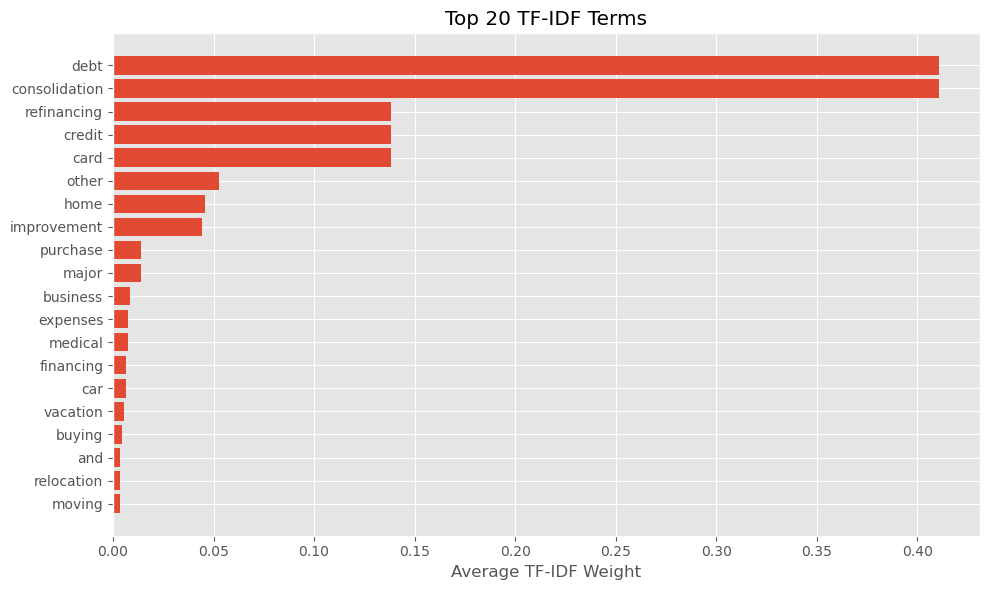

In [62]:
# Plot Top 20 words
# __________________________________________________________

plt.figure(figsize=(10,6))

top20 = tfidf_scores.head(20)

plt.barh(top20["Term"],top20["Mean_TFIDF"])

plt.gca().invert_yaxis()

plt.title("Top 20 TF-IDF Terms")

plt.xlabel("Average TF-IDF Weight")

plt.tight_layout()

plt.savefig(FIGURE_DIR/"top_tfidf_terms.png",dpi=300)

plt.show()

In [63]:
# DOCUMENT FREQUENCY
# __________________________________________________________

logger.info("Calculating document frequencies...")

doc_frequency = np.asarray((X_train_B>0).sum(axis=0)).flatten()

df_report = pd.DataFrame({"Term":feature_names,
                          
                          "Document_Frequency":doc_frequency})

df_report = df_report.sort_values("Document_Frequency",ascending=False)

display(df_report.head())

# Save frequency 

df_report.to_csv(FEATURE_REPORT_DIR/"tfidf_document_frequency.csv",index=False)

2026-07-15 13:06:02,633 | INFO | Calculating document frequencies...


,Term,Document_Frequency
15,debt,232284
11,consolidation,232284
6,card,95834
13,credit,95833
42,refinancing,95832


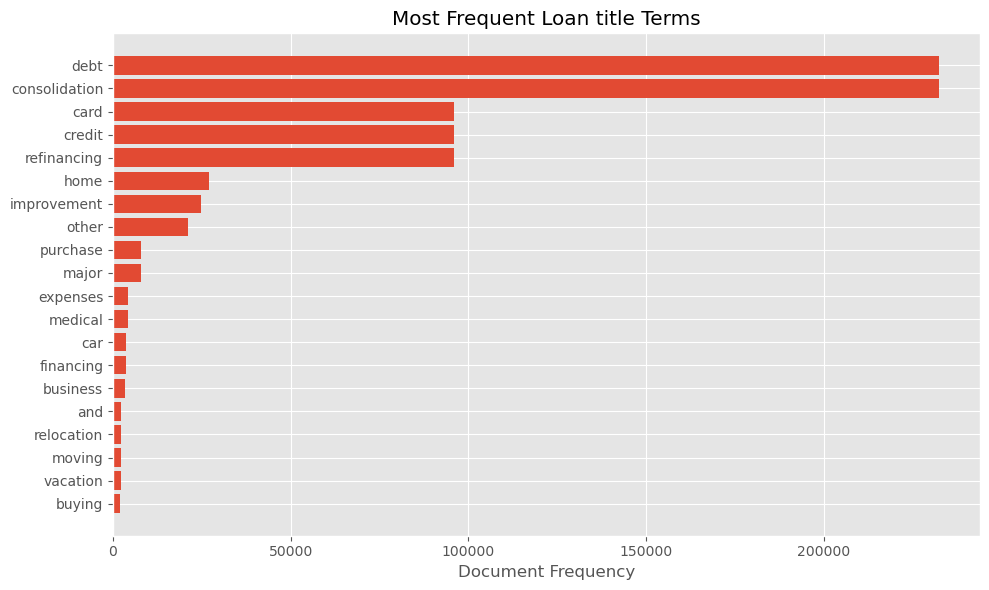

In [64]:
# Plot most frequent loan title
# __________________________________________________________

plt.figure(figsize=(10,6))

top=df_report.head(20)

plt.barh(top["Term"],top["Document_Frequency"])

plt.gca().invert_yaxis()

plt.title("Most Frequent Loan title Terms")

plt.xlabel("Document Frequency")

plt.tight_layout()

plt.savefig(FIGURE_DIR/"tfidf_document_frequency.png",dpi=300)

plt.show()

In [65]:
# Feature Density 
# __________________________________________________________

density_report = pd.DataFrame({

    "Term":feature_names,

    "Non_Zero_Count":np.asarray(

        (X_train_B>0).sum(axis=0)

    ).flatten()})

density_report["Density"]=(

density_report["Non_Zero_Count"]/len(X_train))

display(density_report.head())

# Save density 

density_report.to_csv(FEATURE_REPORT_DIR/"tfidf_feature_density.csv",index=False)

,Term,Non_Zero_Count,Density
0,and,2336,0.005840
1,auto,2,0.000005
2,back,1,0.000003
3,business,3446,0.008615
4,buying,2101,0.005253


In [66]:
# Density caverage
# __________________________________________________________

coverage = pd.DataFrame({

    "Metric":[

        "Unique Terms",

        "Max Features",

        "Coverage (%)"],

    "Value":[

        len(feature_names),500,

        round(len(feature_names)/500*100,2)]})

display(coverage)

,Metric,Value
0,Unique Terms,52.0
1,Max Features,500.0
2,Coverage (%),10.4


In [67]:
# GOVERNANCE REPORT
# __________________________________________________________

report=[]

report.append("TF-IDF GOVERNANCE REPORT")

report.append("")

report.append(f"Training documents : {n_documents}")

report.append(f"Vocabulary size : {n_features}")

report.append(f"Matrix sparsity : {round((1-density)*100,2)} %")

report.append(f"Matrix density : {round(density*100,4)} %")

report.append("")

report.append("Top 10 Terms")

for word in tfidf_scores.head(10)["Term"]:

    report.append(f" • {word}")

report.append("")

report.append("Status : PASSED")

report.append("Ready for Matrix C generation.")

with open(

FEATURE_REPORT_DIR/

"tfidf_governance_report.txt",

"w"

) as f:

    f.write("\n".join(report))

print("\n".join(report[:20]))

TF-IDF GOVERNANCE REPORT

Training documents : 400000
Vocabulary size : 52
Matrix sparsity : 95.81 %
Matrix density : 4.1885 %

Top 10 Terms
 • debt
 • consolidation
 • refinancing
 • credit
 • card
 • other
 • home
 • improvement
 • purchase
 • major

Status : PASSED


In [68]:
# Final Validation
# __________________________________________________________

assert X_train_B.shape[1]==len(feature_names)

assert X_test_B.shape[1]==len(feature_names)

assert X_train_B.shape[0]==len(X_train)

assert X_test_B.shape[0]==len(X_test)

logger.info("TF-IDF quality validation passed.")

2026-07-15 13:06:18,622 | INFO | TF-IDF quality validation passed.


## BUILDING MATRIX C (Structured + NLP Features)
#### Purpose:
#### Matrix C combines:
#### Matrix A
#### Structured Financial Features
####     +
#### Matrix B
#### TF-IDF Loan Purpose Features into one sparse feature matrix.

#### It represents the complete borrower profile.

In [69]:
# BUILD COMBINED FEATURE MATRIX
# __________________________________________________________

logger.info("Building Matrix C...")

X_train_C = hstack([

    X_train_A,

    X_train_B])

X_test_C = hstack([

    X_test_A,

    X_test_B])

print("Training Matrix Shape :", X_train_C.shape)

print("Testing Matrix Shape  :", X_test_C.shape)

2026-07-15 13:06:23,007 | INFO | Building Matrix C...


Training Matrix Shape : (400000, 70)
Testing Matrix Shape  : (100000, 70)


In [70]:
# VALIDATE MATRIX C
# __________________________________________________________

assert X_train_C.shape[0] == len(X_train)

assert X_test_C.shape[0] == len(X_test)

assert X_train_C.shape[1] == (

    X_train_A.shape[1]

    +

    X_train_B.shape[1])

assert X_test_C.shape[1] == (

    X_test_A.shape[1]

    +

    X_test_B.shape[1])

logger.info("Matrix C validation passed.")

2026-07-15 13:06:28,607 | INFO | Matrix C validation passed.


In [71]:
# MATRIX SUMMARY
# __________________________________________________________

combined_summary = pd.DataFrame({"Metric":["Training Rows",
                                           
                                           "Testing Rows",
                                           
                                           "Structured Features",
                                           
                                           "Text Features",
                                           
                                           "Combined Features",
                                           
                                           "Training Non-Zero Values",
                                           
                                           "Testing Non-Zero Values"],
                                 
                                 "Value":[X_train_C.shape[0],
                                          
                                          X_test_C.shape[0],
                                          
                                          X_train_A.shape[1],
                                          
                                          X_train_B.shape[1],
                                          
                                          X_train_C.shape[1],
                                          
                                          X_train_C.nnz,
                                          
                                          X_test_C.nnz]})

display(combined_summary)

# Save model
combined_summary.to_csv(FEATURE_REPORT_DIR/"combined_matrix_summary.csv",index=False)

,Metric,Value
0,Training Rows,400000
1,Testing Rows,100000
2,Structured Features,18
3,Text Features,52
4,Combined Features,70
5,Training Non-Zero Values,4071210
6,Testing Non-Zero Values,1017888


In [72]:
# MATRIX DENSITY
# __________________________________________________________

train_density = (X_train_C.nnz/(X_train_C.shape[0] * X_train_C.shape[1]))

test_density = (X_test_C.nnz/(X_test_C.shape[0] * X_test_C.shape[1]))

density_report = pd.DataFrame({

    "Dataset":[

        "Training",

        "Testing"],

    "Density":[

        train_density,

        test_density],

    "Sparsity (%)":[

        (1-train_density)*100,

        (1-test_density)*100]})

display(density_report)

# Save Report

density_report.to_csv(FEATURE_REPORT_DIR/"combined_matrix_density.csv",index=False)

,Dataset,Density,Sparsity (%)
0,Training,0.145400,85.459964
1,Testing,0.145413,85.458743


In [73]:
# MEMORY USAGE
# __________________________________________________________

memory = pd.DataFrame({

    "Matrix":[

        "Matrix A",

        "Matrix B",

        "Matrix C"],

    "Approx Memory (MB)":[

        X_train_A.data.nbytes/1024**2,

        X_train_B.data.nbytes/1024**2,

        X_train_C.data.nbytes/1024**2]})

display(memory)

# Save memory

memory.to_csv(FEATURE_REPORT_DIR/"feature_memory_usage.csv",index=False)

,Matrix,Approx Memory (MB)
0,Matrix A,54.931641
1,Matrix B,6.646805
2,Matrix C,31.060867


#### Save Matrix C Feature Store 

In [143]:
# CREATE YEARMONTH FROM ISSUE DATE
# _____________________________________________________

logger.info("Creating YearMonth from issue_d...")

datasets = {"Training": X_train,"Testing": X_test}

for name, df in datasets.items():

    # Convert issue_d to datetime
    
    df["issue_d"] = pd.to_datetime(df["issue_d"],format="%b-%Y")

    # Create YearMonth
    
    df["YearMonth"] = (df["issue_d"].dt.to_period("M").astype(str))

    logger.info(f"{name} YearMonth created successfully.")

logger.info("YearMonth creation completed.")

2026-07-17 10:11:39,979 | INFO | Creating YearMonth from issue_d...
2026-07-17 10:11:40,449 | INFO | Training YearMonth created successfully.
2026-07-17 10:11:40,527 | INFO | Testing YearMonth created successfully.
2026-07-17 10:11:40,528 | INFO | YearMonth creation completed.


In [178]:
# CREATE SAFE YEARMONTH FOR MAPPING
# __________________________________________

for name, df in datasets.items():

    df["YearMonth"] = (df["issue_d"].dt.to_period("M").astype(str))

    # Replace NaT conversion result
    
    df["YearMonth"] = df["YearMonth"].replace("NaT",np.nan)
    
    print(name)
    print("Missing YearMonth:",df["YearMonth"].isna().sum())

Training
Missing YearMonth: 1
Testing
Missing YearMonth: 1


In [154]:
# CREATE MATRIX C ROW MAPPING
# ___________________________________________________

logger.info("Creating Matrix C Mapping Files...")

for name, df in datasets.items():

    mapping = pd.DataFrame({

        "row_index": np.arange(len(df)),

        "issue_d": df["issue_d"],

        "YearMonth": df["YearMonth"],

        "loan_status": df["loan_status"]})

    file_name = (FEATURE_STORE_DIR /f"matrix_C_{name.lower()}_mapping.parquet")

    mapping.to_parquet(file_name,index=False)

    logger.info(f"{name} mapping saved successfully.")

    print(f"\n{name} Mapping Preview")

    display(mapping.head())

logger.info("Matrix C Mapping creation completed.")

2026-07-17 10:39:05,024 | INFO | Creating Matrix C Mapping Files...
2026-07-17 10:39:05,185 | INFO | Training mapping saved successfully.



Training Mapping Preview


,row_index,issue_d,YearMonth,loan_status
0,0,2015-01-01,2015-01,Current
1,1,2015-12-01,2015-12,Fully Paid
2,2,2015-05-01,2015-05,Fully Paid
3,3,2018-03-01,2018-03,Current
4,4,2015-09-01,2015-09,Fully Paid


2026-07-17 10:39:05,225 | INFO | Testing mapping saved successfully.



Testing Mapping Preview


,row_index,issue_d,YearMonth,loan_status
0,0,2015-11-01,2015-11,Charged Off
1,1,2015-03-01,2015-03,Fully Paid
2,2,2015-10-01,2015-10,Fully Paid
3,3,2015-10-01,2015-10,Fully Paid
4,4,2018-03-01,2018-03,Current


2026-07-17 10:39:05,228 | INFO | Matrix C Mapping creation completed.


In [163]:
# VALIDATE MATRIX C ROW ALIGNMENT
# _________________________________________________

logger.info("Loading Matrix C sparse matrices...")

matrix_C_train = load_npz(FEATURE_STORE_DIR / "matrix_C_train.npz")

matrix_C_test = load_npz(FEATURE_STORE_DIR / "matrix_C_test.npz")

logger.info("Matrix C loaded successfully.")

# Load mapping files

train_mapping = pd.read_parquet(FEATURE_STORE_DIR / "matrix_C_training_mapping.parquet")

test_mapping = pd.read_parquet(FEATURE_STORE_DIR / "matrix_C_testing_mapping.parquet")

print("Matrix C Train Shape:")
print(matrix_C_train.shape)

print("\nTrain Mapping Shape:")
print(train_mapping.shape)

print("\nMatrix C Test Shape:")
print(matrix_C_test.shape)

print("\nTest Mapping Shape:")
print(test_mapping.shape)

2026-07-17 11:02:43,753 | INFO | Loading Matrix C sparse matrices...
2026-07-17 11:02:43,966 | INFO | Matrix C loaded successfully.


Matrix C Train Shape:
(400000, 70)

Train Mapping Shape:
(400000, 4)

Matrix C Test Shape:
(100000, 70)

Test Mapping Shape:
(100000, 4)


In [165]:
# CHECK ROW INDEX INTEGRITY
# _____________________________________________________

logger.info("Checking row index integrity...")


train_check = (train_mapping["row_index"].equals(pd.Series(
    
    np.arange(len(train_mapping)))))

test_check = (test_mapping["row_index"].equals(pd.Series(
    
    np.arange(len(test_mapping)))))

print("Training Mapping Alignment:",
      "PASS ✅" if train_check else "FAILED ❌")

print("Testing Mapping Alignment:",
      "PASS ✅" if test_check else "FAILED ❌")

2026-07-17 11:05:56,849 | INFO | Checking row index integrity...


Training Mapping Alignment: PASS ✅
Testing Mapping Alignment: PASS ✅


In [176]:
# VALIDATE TEMPORAL ALIGNMENT WITH MACRO FEATURE STORE
# ___________________________________________________

logger.info("Cleaning YearMonth field...")

# Convert YearMonth to string

train_mapping["YearMonth"] = (train_mapping["YearMonth"].astype(str))

test_mapping["YearMonth"] = (test_mapping["YearMonth"].astype(str))

# Remove invalid values

train_mapping = train_mapping[train_mapping["YearMonth"] != "nan"]

test_mapping = test_mapping[test_mapping["YearMonth"] != "nan"]

# Check missing values

print("Training YearMonth Missing:")

print(train_mapping["YearMonth"].isna().sum())


print("\nTesting YearMonth Missing:")

print(test_mapping["YearMonth"].isna().sum())


# Filter macro period

train_macro_period = train_mapping[
    (train_mapping["YearMonth"] >= "2015-01") &
    (train_mapping["YearMonth"] <= "2018-12")]


test_macro_period = test_mapping[
    (test_mapping["YearMonth"] >= "2015-01") &
    (test_mapping["YearMonth"] <= "2018-12")]


print("\nTraining loans 2015-2018:")

print(len(train_macro_period))


print("\nTesting loans 2015-2018:")

print(len(test_macro_period))

2026-07-17 11:21:28,226 | INFO | Cleaning YearMonth field...


Training YearMonth Missing:
0

Testing YearMonth Missing:
0

Training loans 2015-2018:
399999

Testing loans 2015-2018:
99999


In [179]:
# REMOVE INVALID YEARMONTH ROWS
# __________________________________________________________

logger.info("Removing rows with missing YearMonth...")

train_valid_mapping = train_mapping.dropna(subset=["YearMonth"])

test_valid_mapping = test_mapping.dropna(subset=["YearMonth"])

print("Training rows removed:",len(train_mapping) - len(train_valid_mapping))

print("Testing rows removed:",len(test_mapping) - len(test_valid_mapping))

2026-07-17 11:53:01,772 | INFO | Removing rows with missing YearMonth...


Training rows removed: 0
Testing rows removed: 0


In [181]:
# CONVERT MATRIX C TO CSR AND FILTER VALID ROWS
# __________________________________________________

logger.info("Converting Matrix C to CSR format...")

# CSR format supports row slicing

matrix_C_train = matrix_C_train.tocsr()

matrix_C_test = matrix_C_test.tocsr()

logger.info("Matrix C converted to CSR format.")

# Get valid row indices

train_indices = train_valid_mapping["row_index"].values

test_indices = test_valid_mapping["row_index"].values

# Select valid rows

matrix_C_train_valid = matrix_C_train[train_indices]

matrix_C_test_valid = matrix_C_test[test_indices]

print("Filtered Matrix C Train Shape:")

print(matrix_C_train_valid.shape)

print("\nFiltered Matrix C Test Shape:")
print(matrix_C_test_valid.shape)

2026-07-17 11:59:29,489 | INFO | Converting Matrix C to CSR format...
2026-07-17 11:59:29,586 | INFO | Matrix C converted to CSR format.


Filtered Matrix C Train Shape:
(400000, 70)

Filtered Matrix C Test Shape:
(100000, 70)


In [193]:
# COMBINED FEATURE NAMES
# __________________________________________________________

# Load previously exported structured feature names

structured_features = pd.read_csv(PROCESSED_DATA_DIR / "structured_feature_names.csv")

# Convert to list

structured_features = structured_features["Feature_Name"].tolist()

# TF-IDF feature names

tfidf_features = (tfidf_vectorizer.get_feature_names_out().tolist())

# Combine both feature sets

combined_feature_names = structured_features + tfidf_features

# Create dataframe

combined_features = pd.DataFrame({
   
    "Feature_ID": range(len(combined_feature_names)),
    
    "Feature_Name": combined_feature_names,
    
    "Feature_Type": (
    
        ["Structured"] * len(structured_features)
        
        + ["NLP_TFIDF"] * len(tfidf_features))})

display(combined_features.head())

print(combined_features.shape)

# Save

combined_features.to_csv(FEATURE_REPORT_DIR / "combined_feature_names.csv",index=False)

logger.info("Combined feature names exported.")

,Feature_ID,Feature_Name,Feature_Type
0,0,numeric__loan_amnt,Structured
1,1,numeric__int_rate,Structured
2,2,numeric__annual_inc,Structured
3,3,numeric__dti,Structured
4,4,numeric__revol_util,Structured


2026-07-19 02:10:00,991 | INFO | Combined feature names exported.


(70, 3)


In [75]:
# GOVERNANCE REPORT
# __________________________________________________________

report=[]

report.append("COMBINED FEATURE MATRIX REPORT")

report.append("="*50)

report.append("")

report.append(f"Structured Features : {X_train_A.shape[1]}")

report.append(f"Text Features       : {X_train_B.shape[1]}")

report.append(f"Combined Features   : {X_train_C.shape[1]}")

report.append("")

report.append(f"Training Density : {train_density:.6f}")

report.append(f"Testing Density : {test_density:.6f}")

report.append("")

report.append("Matrix C successfully created.")

report.append("Ready for Model Development.")

with open(FEATURE_REPORT_DIR/"combined_matrix_report.txt",

"w") as f:f.write("\n".join(report))

print("\n".join(report))

COMBINED FEATURE MATRIX REPORT

Structured Features : 18
Text Features       : 52
Combined Features   : 70

Training Density : 0.145400
Testing Density : 0.145413

Matrix C successfully created.
Ready for Model Development.


### Export Feature Names

##### Purpose:
##### Create a complete feature dictionary mapping model inputs
##### back to business-readable variables.

In [76]:
# Export Feature Dictionary
# __________________________________________________________

logger.info("Exporting feature names...")

# Structured features from Matrix A

structured_df = pd.read_csv(PROCESSED_DATA_DIR / "structured_feature_names.csv")

structured_feature_names = structured_df["Feature_Name"].tolist()


# NLP features from Matrix B

nlp_feature_names = (tfidf_vectorizer.get_feature_names_out())

# Combined feature list

all_feature_names = list(structured_feature_names) + list(nlp_feature_names)


# Create dataframe

feature_dictionary = pd.DataFrame({

    "Feature_ID":range(len(all_feature_names)),

    "Feature_Name":all_feature_names,

    "Feature_Type":[

            "Structured"

            if i < len(structured_feature_names)

            else "NLP_TFIDF"

            for i in range(len(all_feature_names))]})


display(feature_dictionary.head())

print("Total Features:",len(feature_dictionary))

feature_dictionary.to_csv(FEATURE_REPORT_DIR /"feature_dictionary.csv",index=False)

2026-07-15 13:06:48,500 | INFO | Exporting feature names...


,Feature_ID,Feature_Name,Feature_Type
0,0,numeric__loan_amnt,Structured
1,1,numeric__int_rate,Structured
2,2,numeric__annual_inc,Structured
3,3,numeric__dti,Structured
4,4,numeric__revol_util,Structured


Total Features: 70


### Save Feature Matrices

##### Purpose :

##### Persist all feature matrices and preprocessing artefacts for downstream
##### modelling and deployment.

In [77]:
# SAVE MATRIX A
# __________________________________________________________

logger.info("Saving Matrix A...")

joblib.dump(X_train_A,FEATURE_STORE_DIR / "matrix_A_train.pkl")

joblib.dump(X_test_A,FEATURE_STORE_DIR / "matrix_A_test.pkl")

logger.info("Matrix A saved.")

2026-07-15 13:06:51,344 | INFO | Saving Matrix A...
2026-07-15 13:06:51,400 | INFO | Matrix A saved.


In [78]:
# SAVE MATRIX B
# __________________________________________________________

logger.info("Saving Matrix B...")

save_npz(FEATURE_STORE_DIR /"matrix_B_train.npz",X_train_B)

save_npz(FEATURE_STORE_DIR /"matrix_B_test.npz",X_test_B)

logger.info("Matrix B saved.")

2026-07-15 13:06:52,133 | INFO | Saving Matrix B...
2026-07-15 13:06:52,691 | INFO | Matrix B saved.


In [79]:
# SAVE MATRIX C
# __________________________________________________________

logger.info("Saving Matrix C...")

save_npz(FEATURE_STORE_DIR /"matrix_C_train.npz",X_train_C)

save_npz(FEATURE_STORE_DIR /"matrix_C_test.npz",X_test_C)

logger.info("Matrix C saved.")

2026-07-15 13:06:52,940 | INFO | Saving Matrix C...
2026-07-15 13:06:55,046 | INFO | Matrix C saved.


In [80]:
# SAVE TARGET VARIABLES
# __________________________________________________________

logger.info("Saving target variables...")

y_train.to_csv(FEATURE_STORE_DIR /"y_train.csv",index=False)

y_test.to_csv(FEATURE_STORE_DIR /"y_test.csv",index=False)

logger.info("Target variables saved.")

2026-07-15 13:06:57,502 | INFO | Saving target variables...
2026-07-15 13:06:57,667 | INFO | Target variables saved.


In [81]:
# SAVE PREPROCESSING OBJECTS
# __________________________________________________________

logger.info("Saving preprocessing artefacts...")

joblib.dump(tfidf_vectorizer,PREPROCESSING_DIR /"tfidf_vectorizer.pkl")

logger.info("Preprocessing artefacts saved.")

2026-07-15 13:06:58,976 | INFO | Saving preprocessing artefacts...
2026-07-15 13:06:58,981 | INFO | Preprocessing artefacts saved.


In [82]:
# SAVE FEATURE DICTIONARY
# __________________________________________________________

feature_dictionary.to_csv(FEATURE_STORE_DIR /"feature_dictionary.csv",index=False)

logger.info("Feature dictionary saved.")

2026-07-15 13:07:00,164 | INFO | Feature dictionary saved.


In [86]:
joblib.dump(tfidf_vectorizer,PREPROCESSING_DIR / "tfidf_vectorizer.pkl")

logger.info("TF-IDF Vectorizer saved successfully.")

2026-07-15 13:07:17,556 | INFO | TF-IDF Vectorizer saved successfully.


In [87]:
# FEATURE STORE INVENTORY
# __________________________________________________________

artifact_inventory = pd.DataFrame({

    "Artifact":[

        "Matrix A Train",

        "Matrix A Test",

        "Matrix B Train",

        "Matrix B Test",

        "Matrix C Train",

        "Matrix C Test",

        "Training Labels",

        "Testing Labels",

        "Structured Preprocessor",

        "TF-IDF Vectorizer",

        "Feature Dictionary"],

    "File":[

        "matrix_A_train.pkl",

        "matrix_A_test.pkl",

        "matrix_B_train.npz",

        "matrix_B_test.npz",

        "matrix_C_train.npz",

        "matrix_C_test.npz",

        "y_train.csv",

        "y_test.csv",

        "structured_preprocessor.pkl",

        "tfidf_vectorizer.pkl",

        "feature_dictionary.csv"]})

display(artifact_inventory)

# Save Inventory

artifact_inventory.to_csv(FEATURE_REPORT_DIR /"artifact_inventory.csv",index=False)

logger.info("Artifact inventory exported.")

,Artifact,File
0,Matrix A Train,matrix_A_train.pkl
1,Matrix A Test,matrix_A_test.pkl
2,Matrix B Train,matrix_B_train.npz
3,Matrix B Test,matrix_B_test.npz
4,Matrix C Train,matrix_C_train.npz
5,Matrix C Test,matrix_C_test.npz
6,Training Labels,y_train.csv
7,Testing Labels,y_test.csv
8,Structured Preprocessor,structured_preprocessor.pkl
9,TF-IDF Vectorizer,tfidf_vectorizer.pkl


2026-07-15 13:07:19,421 | INFO | Artifact inventory exported.


In [89]:
# VERIFY FILES
# __________________________________________________________

required_files = [

    FEATURE_STORE_DIR / "matrix_A_train.pkl",

    FEATURE_STORE_DIR / "matrix_A_test.pkl",

    FEATURE_STORE_DIR / "matrix_B_train.npz",

    FEATURE_STORE_DIR / "matrix_B_test.npz",

    FEATURE_STORE_DIR / "matrix_C_train.npz",

    FEATURE_STORE_DIR / "matrix_C_test.npz",

    FEATURE_STORE_DIR / "y_train.csv",

    FEATURE_STORE_DIR / "y_test.csv",

    FEATURE_STORE_DIR / "feature_dictionary.csv",

    PREPROCESSING_DIR / "structured_preprocessor.pkl",

    PREPROCESSING_DIR / "tfidf_vectorizer.pkl"]

for file in required_files:
    
    if file.exists():

        print(f"✓ {file.name}")

else:print(f"✗ Missing: {file.name}")

✓ matrix_A_train.pkl
✓ matrix_A_test.pkl
✓ matrix_B_train.npz
✓ matrix_B_test.npz
✓ matrix_C_train.npz
✓ matrix_C_test.npz
✓ y_train.csv
✓ y_test.csv
✓ feature_dictionary.csv
✓ tfidf_vectorizer.pkl
✗ Missing: tfidf_vectorizer.pkl


In [90]:
# FEATURE STORE SUMMARY
# __________________________________________________________

feature_store_summary = pd.DataFrame({

    "Metric":[

        "Matrix A Shape",

        "Matrix B Shape",

        "Matrix C Shape",

        "Structured Features",

        "NLP Features",

        "Combined Features"],

    "Value":[

        str(X_train_A.shape),

        str(X_train_B.shape),

        str(X_train_C.shape),

        X_train_A.shape[1],

        X_train_B.shape[1],

        X_train_C.shape[1]]})

display(feature_store_summary)

feature_store_summary.to_csv(FEATURE_REPORT_DIR /"feature_store_summary.csv",index=False)

logger.info("Feature store summary exported.")

,Metric,Value
0,Matrix A Shape,"(400000, 18)"
1,Matrix B Shape,"(400000, 52)"
2,Matrix C Shape,"(400000, 70)"
3,Structured Features,18
4,NLP Features,52
5,Combined Features,70


2026-07-15 13:09:17,587 | INFO | Feature store summary exported.
